# T2: Modelagem Supervisionada — Dataset HCV

Este notebook implementa e compara três classificadores supervisionados (KNN, Árvore de Decisão e Rede Neural MLP) sobre o dataset HCV (Hepatitis C Virus), que contém dados laboratoriais de pacientes em diferentes estágios da doença hepática.

## Passo 0 — Criar Pasta de Figuras

Antes de qualquer outra coisa, garantimos que a pasta `figuras/` existe para armazenar os gráficos gerados ao longo do notebook.

In [1]:
import os
os.makedirs('figuras', exist_ok=True)

## Passo 1 — Importações e Configuração

Importamos todas as bibliotecas necessárias e fixamos a semente de aleatoriedade em 42 para garantir reprodutibilidade dos resultados em todas as etapas.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import warnings
warnings.filterwarnings('ignore')

# Semente de aleatoriedade — use 42 em TODOS os pontos do código
RANDOM_STATE = 42
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

## Passo 2 — Carregamento e Exploração dos Dados

Carregamos o dataset HCV a partir do arquivo CSV. A primeira coluna é usada como índice do DataFrame e os valores `NA` são reconhecidos como valores ausentes (NaN). Em seguida, exploramos a estrutura básica dos dados: forma, primeiras linhas, tipos de colunas, distribuição das classes e contagem de valores faltantes.

In [ ]:
# A primeira coluna (índice sem nome) deve ser usada como índice do DataFrame.
# Os valores 'NA' devem ser reconhecidos como NaN pelo pandas.

df = pd.read_csv('../data/hcvdat0.csv', index_col=0, na_values='NA')

# Exiba as informações básicas do dataset
print("Shape:", df.shape)
print()
print(df.head())
print()
print(df.info())
print()
print("Distribuição das classes:")
print(df['Category'].value_counts())
print()
print("Valores ausentes por coluna:")
print(df.isnull().sum())

Shape: (615, 13)

        Category  Age Sex   ALB   ALP   ALT   AST   BIL    CHE  CHOL   CREA  \
1  0=Blood Donor   32   m  38.5  52.5   7.7  22.1   7.5   6.93  3.23  106.0   
2  0=Blood Donor   32   m  38.5  70.3  18.0  24.7   3.9  11.17  4.80   74.0   
3  0=Blood Donor   32   m  46.9  74.7  36.2  52.6   6.1   8.84  5.20   86.0   
4  0=Blood Donor   32   m  43.2  52.0  30.6  22.6  18.9   7.33  4.74   80.0   
5  0=Blood Donor   32   m  39.2  74.1  32.6  24.8   9.6   9.15  4.32   76.0   

    GGT  PROT  
1  12.1  69.0  
2  15.6  76.5  
3  33.2  79.3  
4  33.8  75.7  
5  29.9  68.7  

<class 'pandas.DataFrame'>
RangeIndex: 615 entries, 1 to 615
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Category  615 non-null    str    
 1   Age       615 non-null    int64  
 2   Sex       615 non-null    str    
 3   ALB       614 non-null    float64
 4   ALP       597 non-null    float64
 5   ALT       614 non-null    float64
 6  

## Passo 3 — Pré-Processamento

O pré-processamento é dividido em etapas bem definidas para garantir que não haja vazamento de dados (data leakage) entre treino, validação e teste.

### 3.1 — Consolidação dos Rótulos

A classe `'0s=suspect Blood Donor'` possui apenas 7 instâncias e semântica intermediária entre doador saudável e hepatite. Com tão poucos exemplos, qualquer modelo teria dificuldade em aprender um padrão confiável para essa classe. A decisão foi mesclá-la com `'0=Blood Donor'`. As demais classes foram renomeadas para nomes mais curtos e legíveis.

In [4]:
# A classe '0s=suspect Blood Donor' tem apenas 7 instâncias e semântica
# intermediária. Foi mesclada com '0=Blood Donor' para evitar que o modelo
# tente aprender um padrão com exemplos insuficientes.
# As demais classes foram renomeadas para nomes mais curtos.

mapa_classes = {
    '0=Blood Donor':          'Blood Donor',
    '0s=suspect Blood Donor': 'Blood Donor',
    '1=Hepatitis':            'Hepatitis',
    '2=Fibrosis':             'Fibrosis',
    '3=Cirrhosis':            'Cirrhosis',
}
df['Category'] = df['Category'].map(mapa_classes)

print("Classes após consolidação:")
print(df['Category'].value_counts())

Classes após consolidação:
Category
Blood Donor    540
Cirrhosis       30
Hepatitis       24
Fibrosis        21
Name: count, dtype: int64


### 3.2 — Codificação do Atributo Categórico `Sex`

`Sex` é uma variável binária (m/f). Como só existem dois valores possíveis, a codificação numérica direta não introduz nenhuma relação de ordem espúria — não há problema em usar `m=1` e `f=0` diretamente.

In [5]:
# Sex é uma variável binária (m/f), então a codificação numérica direta
# não introduz relação de ordem espúria entre os valores.
# m → 1, f → 0

df['Sex'] = df['Sex'].map({'m': 1, 'f': 0})

print("Valores únicos em Sex após codificação:", df['Sex'].unique())

Valores únicos em Sex após codificação: [1 0]


### 3.3 — Separação de X e y

Separamos as features (X) do rótulo (y) antes de qualquer divisão. O `LabelEncoder` é aplicado em `y` antes da divisão porque ele apenas mapeia nomes de classes para inteiros — não usa informação estatística dos dados, portanto não há risco de vazamento.

In [6]:
# Separamos features e rótulo antes de qualquer divisão ou imputação.
# O LabelEncoder é aplicado em y antes da divisão porque ele apenas
# mapeia os nomes das classes para inteiros — não usa informação dos dados
# em si, então não há risco de vazamento.

X = df.drop(columns=['Category'])
y = df['Category']

le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = le.classes_

print("Classes codificadas:", class_names)
print("Mapeamento:", dict(zip(class_names, le.transform(class_names))))

Classes codificadas: ['Blood Donor' 'Cirrhosis' 'Fibrosis' 'Hepatitis']
Mapeamento: {'Blood Donor': np.int64(0), 'Cirrhosis': np.int64(1), 'Fibrosis': np.int64(2), 'Hepatitis': np.int64(3)}


### 3.4 — Divisão em Treino, Validação e Teste (Estratificada)

Dividimos os dados em 70% treino, 15% validação e 15% teste. A estratificação garante que a proporção de cada classe seja preservada nos três conjuntos — essencial dado o forte desbalanceamento do dataset (cerca de 86% de `Blood Donor`). O conjunto de teste é separado aqui e **não será utilizado até a avaliação final** no Passo 8.

In [7]:
# Divisão: 70% treino, 15% validação, 15% teste.
# stratify=y_encoded garante que a proporção de cada classe seja preservada
# nos três conjuntos, o que é importante dado o forte desbalanceamento.
#
# O conjunto de TESTE deve ser separado aqui e não utilizado novamente
# até a avaliação final no Passo 8.

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print(f"Treino:    {X_train.shape[0]} instâncias")
print(f"Validação: {X_val.shape[0]} instâncias")
print(f"Teste:     {X_test.shape[0]} instâncias")

# Confirme a proporção de classes no treino
print("\nProporção de classes no treino:")
for i, nome in enumerate(class_names):
    n = (y_train == i).sum()
    print(f"  {nome}: {n} ({n/len(y_train)*100:.1f}%)")

Treino:    430 instâncias
Validação: 92 instâncias
Teste:     93 instâncias

Proporção de classes no treino:
  Blood Donor: 377 (87.7%)
  Cirrhosis: 21 (4.9%)
  Fibrosis: 15 (3.5%)
  Hepatitis: 17 (4.0%)


### 3.5 — Imputação de Valores Faltantes pela Mediana

Alguns atributos (como `ALP` e `ALB`) possuem valores ausentes. Usamos a mediana de cada coluna para preenchê-los, pois a mediana é mais robusta a outliers do que a média. Os parâmetros de imputação são calculados **apenas sobre o treino** e depois aplicados a validação e teste — isso evita data leakage.

In [8]:
# Os parâmetros de imputação (mediana de cada coluna) são calculados
# APENAS sobre o treino e depois aplicados a validação e teste.
# Isso evita data leakage: o modelo não pode "espiar" os dados de teste
# nem mesmo para calcular uma mediana.

imputer = SimpleImputer(strategy='median')
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X.columns)
X_val   = pd.DataFrame(imputer.transform(X_val),       columns=X.columns)
X_test  = pd.DataFrame(imputer.transform(X_test),      columns=X.columns)

# Verificação: nenhum NaN deve restar
assert X_train.isnull().sum().sum() == 0, "Ainda há NaN no treino!"
assert X_val.isnull().sum().sum()   == 0, "Ainda há NaN na validação!"
assert X_test.isnull().sum().sum()  == 0, "Ainda há NaN no teste!"
print("Imputação concluída. Nenhum valor faltante restante.")

Imputação concluída. Nenhum valor faltante restante.


### 3.6 — Normalização Min-Max

Os atributos têm escalas muito diferentes (ex.: `Age` em dezenas, `CREA` em centenas). O `MinMaxScaler` projeta todos para o intervalo [0, 1], o que é especialmente importante para o KNN (que usa distância euclidiana) e para a convergência da rede neural. Assim como na imputação, o scaler é ajustado **apenas no treino**.

In [9]:
# Os atributos têm escalas muito diferentes (Age em dezenas, CREA em centenas).
# O MinMaxScaler projeta todos para [0, 1].
# Assim como na imputação, o scaler é ajustado APENAS no treino.

scaler = MinMaxScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_val_scaled   = pd.DataFrame(scaler.transform(X_val),       columns=X.columns)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=X.columns)

print("Intervalo dos atributos após normalização (treino):")
print(X_train_scaled.describe().loc[['min', 'max']].T)

Intervalo dos atributos após normalização (treino):
      min  max
Age   0.0  1.0
Sex   0.0  1.0
ALB   0.0  1.0
ALP   0.0  1.0
ALT   0.0  1.0
AST   0.0  1.0
BIL   0.0  1.0
CHE   0.0  1.0
CHOL  0.0  1.0
CREA  0.0  1.0
GGT   0.0  1.0
PROT  0.0  1.0


### 3.7 — Pesos de Classe

Com aproximadamente 86% dos dados sendo `Blood Donor`, um modelo ingênuo poderia classificar tudo como saudável e ainda obter alta acurácia. Os pesos de classe penalizam proporcionalmente mais os erros nas classes minoritárias (Hepatitis, Fibrosis, Cirrhosis), forçando o modelo a prestar mais atenção a elas.

In [10]:
# Com 86% dos dados sendo 'Blood Donor', um modelo ingênuo classificaria
# tudo como saudável e ainda teria alta acurácia. Os pesos de classe
# penalizam proporcionalmente mais os erros nas classes minoritárias.

classes_unicas = np.unique(y_train)
pesos = compute_class_weight(
    class_weight='balanced',
    classes=classes_unicas,
    y=y_train
)
class_weights_dict = dict(zip(classes_unicas, pesos))

print("Pesos de classe calculados:")
for i, peso in class_weights_dict.items():
    print(f"  {class_names[i]}: {peso:.4f}")

Pesos de classe calculados:
  Blood Donor: 0.2851
  Cirrhosis: 5.1190
  Fibrosis: 7.1667
  Hepatitis: 6.3235


## Passo 4 — Função Auxiliar de Avaliação

Criamos uma função reutilizável que calcula as métricas de classificação (acurácia, precisão, recall e F1-Score, todos na média macro) e gera a matriz de confusão para qualquer modelo. A média macro trata todas as classes igualmente, o que é adequado quando nos importamos com o desempenho nas classes minoritárias.

In [11]:
def avaliar_modelo(nome, y_true, y_pred, classes, nome_arquivo):
    """
    Calcula e exibe métricas de classificação e salva a matriz de confusão.

    Parâmetros:
        nome         : nome do modelo para exibição
        y_true       : rótulos verdadeiros
        y_pred       : rótulos preditos
        classes      : lista com os nomes das classes (na ordem dos inteiros)
        nome_arquivo : prefixo do arquivo de imagem a ser salvo em figuras/
    """
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)

    print(f"\n{'='*55}")
    print(f"  {nome}")
    print(f"{'='*55}")
    print(f"  Acurácia  : {acc:.4f}")
    print(f"  Precisão  : {prec:.4f}  (macro)")
    print(f"  Recall    : {rec:.4f}  (macro)")
    print(f"  F1-Score  : {f1:.4f}  (macro)")
    print()
    print(classification_report(y_true, y_pred, target_names=classes, zero_division=0))

    # Matriz de confusão
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Matriz de Confusão: {nome}')
    plt.tight_layout()
    caminho = f'figuras/cm_{nome_arquivo}.png'
    plt.savefig(caminho, dpi=150)
    plt.show()
    print(f"Figura salva em: {caminho}")

    return {'modelo': nome, 'acuracia': acc, 'precisao': prec, 'recall': rec, 'f1': f1}

## Passo 5 — KNN (K-Nearest Neighbors)

O KNN classifica cada instância com base nos `k` vizinhos mais próximos no espaço de features. Por usar distância euclidiana, é sensível à escala dos atributos — por isso usamos os dados normalizados. Precisamos encontrar o melhor valor de `k` sem usar o conjunto de teste.

### 5.1 — Busca do Melhor k na Validação

Testamos diferentes valores de `k` e escolhemos aquele que maximiza o F1-Score macro no conjunto de **validação**. O conjunto de teste não é usado aqui.

k= 3  ->  F1-val = 0.4368
k= 5  ->  F1-val = 0.5299
k= 7  ->  F1-val = 0.6313
k= 9  ->  F1-val = 0.6313
k=11  ->  F1-val = 0.4035
k=15  ->  F1-val = 0.4035

Melhor k: 7  (F1-val = 0.6313)


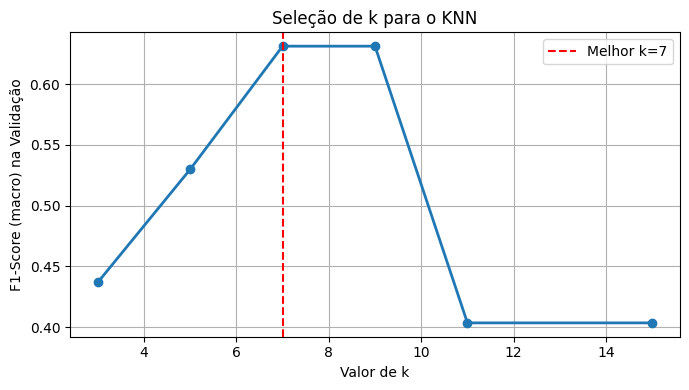

In [12]:
# Teste k em [3, 5, 7, 9, 11, 15].
# Para cada k, treine com os dados normalizados e avalie o F1-Score macro
# no conjunto de validação. O teste NÃO é usado aqui.

k_valores = [3, 5, 7, 9, 11, 15]
resultados_k = []

for k in k_valores:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn.fit(X_train_scaled, y_train)
    y_pred_val = knn.predict(X_val_scaled)
    f1_val = f1_score(y_val, y_pred_val, average='macro', zero_division=0)
    resultados_k.append(f1_val)
    print(f"k={k:2d}  ->  F1-val = {f1_val:.4f}")

melhor_k = k_valores[np.argmax(resultados_k)]
print(f"\nMelhor k: {melhor_k}  (F1-val = {max(resultados_k):.4f})")

# Gráfico de seleção de k
plt.figure(figsize=(7, 4))
plt.plot(k_valores, resultados_k, marker='o', linewidth=2)
plt.axvline(melhor_k, color='red', linestyle='--', label=f'Melhor k={melhor_k}')
plt.xlabel('Valor de k')
plt.ylabel('F1-Score (macro) na Validação')
plt.title('Seleção de k para o KNN')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('figuras/knn_selecao_k.png', dpi=150)
plt.show()

### 5.2 — Treinamento e Avaliação Final do KNN

Com o melhor `k` encontrado na validação, treinamos o modelo final e avaliamos tanto na validação quanto no **teste** (primeira e única vez que o teste é usado para o KNN).


  KNN (k=7) - Validacao
  Acurácia  : 0.9239
  Precisão  : 0.9801  (macro)
  Recall    : 0.5208  (macro)
  F1-Score  : 0.6313  (macro)

              precision    recall  f1-score   support

 Blood Donor       0.92      1.00      0.96        81
   Cirrhosis       1.00      0.50      0.67         4
    Fibrosis       1.00      0.33      0.50         3
   Hepatitis       1.00      0.25      0.40         4

    accuracy                           0.92        92
   macro avg       0.98      0.52      0.63        92
weighted avg       0.93      0.92      0.91        92



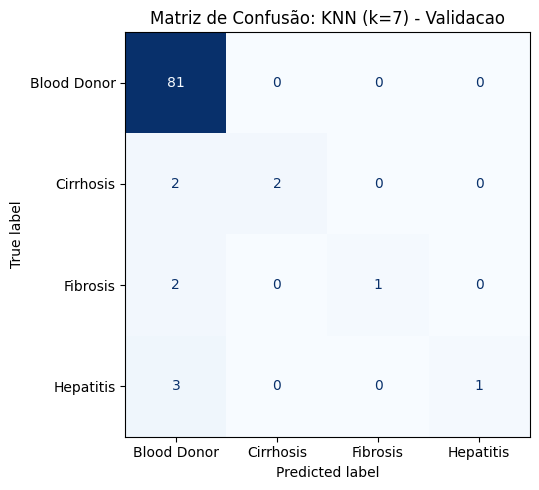

Figura salva em: figuras/cm_knn_val.png

  KNN (k=7) - Teste
  Acurácia  : 0.9247
  Precisão  : 0.6705  (macro)
  Recall    : 0.4833  (macro)
  F1-Score  : 0.5328  (macro)

              precision    recall  f1-score   support

 Blood Donor       0.93      1.00      0.96        82
   Cirrhosis       0.75      0.60      0.67         5
    Fibrosis       1.00      0.33      0.50         3
   Hepatitis       0.00      0.00      0.00         3

    accuracy                           0.92        93
   macro avg       0.67      0.48      0.53        93
weighted avg       0.89      0.92      0.90        93



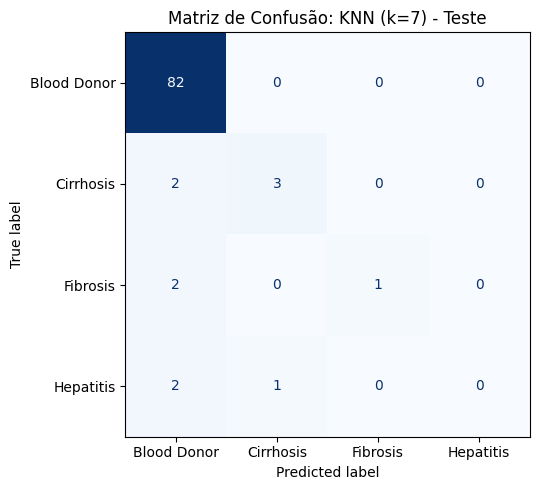

Figura salva em: figuras/cm_knn_teste.png


In [13]:
knn_final = KNeighborsClassifier(n_neighbors=melhor_k, metric='euclidean')
knn_final.fit(X_train_scaled, y_train)

y_pred_knn_val  = knn_final.predict(X_val_scaled)
y_pred_knn_test = knn_final.predict(X_test_scaled)

metricas_knn_val  = avaliar_modelo(
    f'KNN (k={melhor_k}) - Validacao', y_val,  y_pred_knn_val,  class_names, f'knn_val'
)
metricas_knn_test = avaliar_modelo(
    f'KNN (k={melhor_k}) - Teste',     y_test, y_pred_knn_test, class_names, f'knn_teste'
)

## Passo 6 — Árvore de Decisão

A Árvore de Decisão particiona o espaço de features recursivamente usando o critério de Gini. É um modelo interpretável que permite visualizar as regras de decisão aprendidas. O principal hiperparâmetro a ajustar é a profundidade máxima (`max_depth`), que controla o balanço entre capacidade e regularização.

### 6.1 — Busca da Melhor Profundidade na Validação

Testamos diferentes valores de `max_depth` e escolhemos o que maximiza o F1-Score macro na validação. `class_weight='balanced'` é usado em todos os testes para não favorecer a classe majoritária durante a busca.

In [14]:
# Teste max_depth em [3, 5, 7, 10, None].
# None significa sem limite de profundidade.
# class_weight='balanced' é usado em todos os testes para não favorecer
# a classe majoritária durante a busca.

profundidades = [3, 5, 7, 10, None]
resultados_depth = []

for depth in profundidades:
    dt = DecisionTreeClassifier(
        criterion='gini',
        max_depth=depth,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=RANDOM_STATE
    )
    dt.fit(X_train_scaled, y_train)
    y_pred_val = dt.predict(X_val_scaled)
    f1_val = f1_score(y_val, y_pred_val, average='macro', zero_division=0)
    resultados_depth.append(f1_val)
    print(f"max_depth={str(depth):6s}  ->  F1-val = {f1_val:.4f}")

melhor_depth = profundidades[np.argmax(resultados_depth)]
print(f"\nMelhor max_depth: {melhor_depth}  (F1-val = {max(resultados_depth):.4f})")

max_depth=3       ->  F1-val = 0.5802
max_depth=5       ->  F1-val = 0.6331
max_depth=7       ->  F1-val = 0.7233
max_depth=10      ->  F1-val = 0.7499
max_depth=None    ->  F1-val = 0.7499

Melhor max_depth: 10  (F1-val = 0.7499)


### 6.2 — Treinamento e Avaliação Final da Árvore

Treinamos a árvore final com a melhor profundidade e avaliamos nos conjuntos de validação e **teste**.


  Arvore (depth=10) - Validacao
  Acurácia  : 0.9457
  Precisão  : 0.8910  (macro)
  Recall    : 0.7052  (macro)
  F1-Score  : 0.7499  (macro)

              precision    recall  f1-score   support

 Blood Donor       0.96      0.99      0.98        81
   Cirrhosis       0.60      0.75      0.67         4
    Fibrosis       1.00      0.33      0.50         3
   Hepatitis       1.00      0.75      0.86         4

    accuracy                           0.95        92
   macro avg       0.89      0.71      0.75        92
weighted avg       0.95      0.95      0.94        92



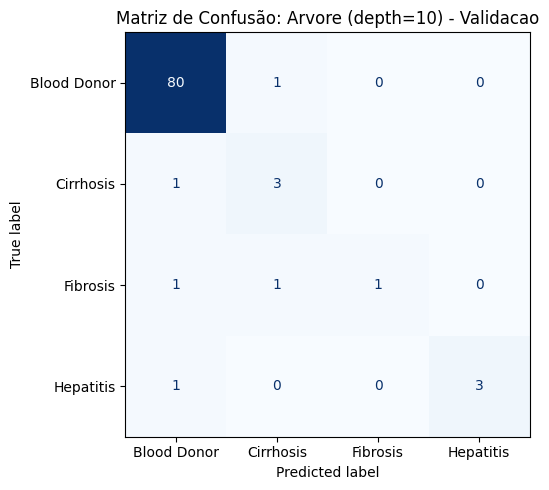

Figura salva em: figuras/cm_dt_val.png

  Arvore (depth=10) - Teste
  Acurácia  : 0.9032
  Precisão  : 0.3868  (macro)
  Recall    : 0.4439  (macro)
  F1-Score  : 0.4106  (macro)

              precision    recall  f1-score   support

 Blood Donor       0.98      0.98      0.98        82
   Cirrhosis       0.57      0.80      0.67         5
    Fibrosis       0.00      0.00      0.00         3
   Hepatitis       0.00      0.00      0.00         3

    accuracy                           0.90        93
   macro avg       0.39      0.44      0.41        93
weighted avg       0.89      0.90      0.90        93



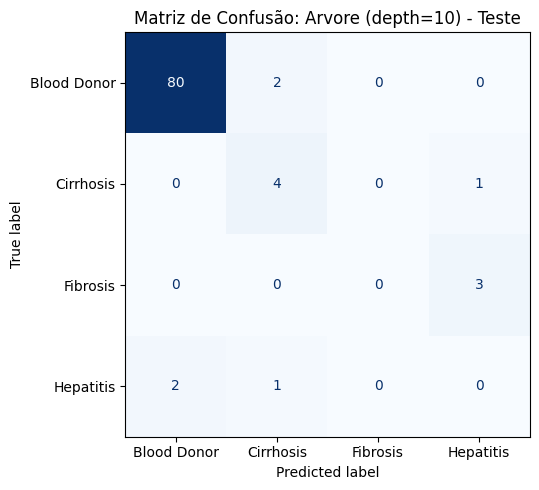

Figura salva em: figuras/cm_dt_teste.png


In [15]:
dt_final = DecisionTreeClassifier(
    criterion='gini',
    max_depth=melhor_depth,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
dt_final.fit(X_train_scaled, y_train)

y_pred_dt_val  = dt_final.predict(X_val_scaled)
y_pred_dt_test = dt_final.predict(X_test_scaled)

metricas_dt_val  = avaliar_modelo(
    f'Arvore (depth={melhor_depth}) - Validacao', y_val,  y_pred_dt_val,  class_names, 'dt_val'
)
metricas_dt_test = avaliar_modelo(
    f'Arvore (depth={melhor_depth}) - Teste',     y_test, y_pred_dt_test, class_names, 'dt_teste'
)

### 6.3 — Visualização da Árvore e Importância dos Atributos

Visualizamos os primeiros 3 níveis da árvore (independente da profundidade real) para manter a legibilidade. Em seguida, plotamos a importância de cada atributo segundo o critério de Gini — atributos que aparecem mais próximos da raiz e separam melhor as classes recebem maior importância.

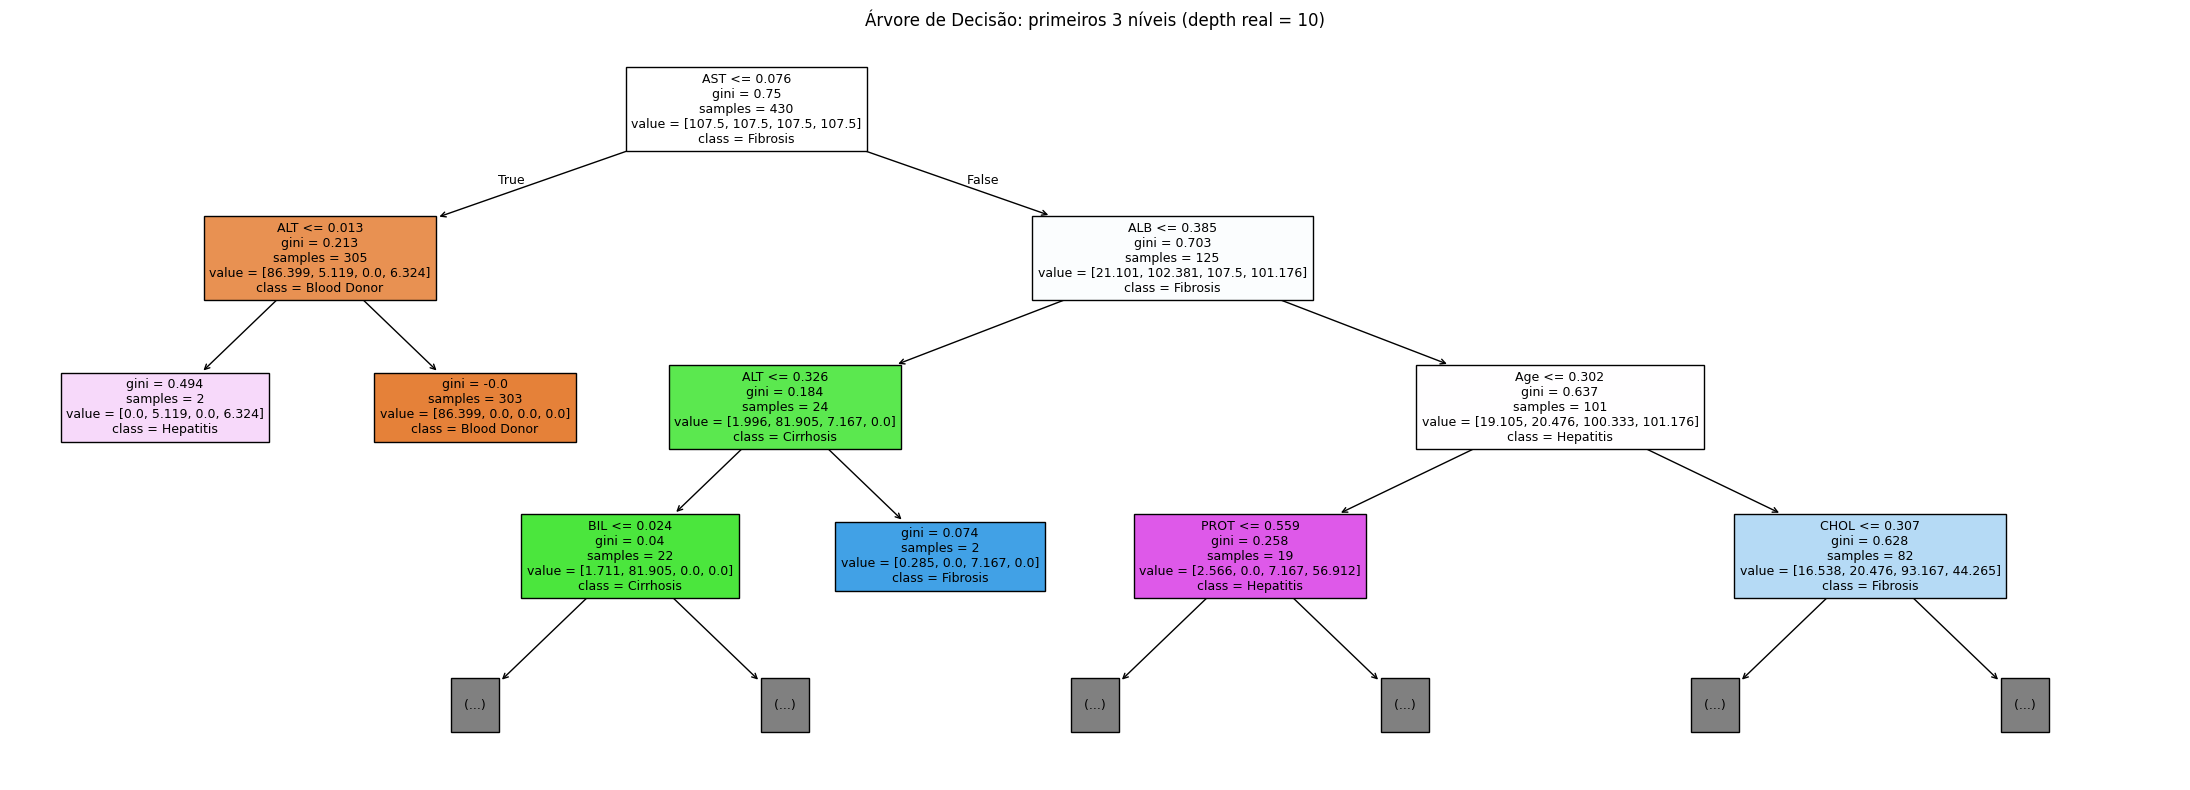

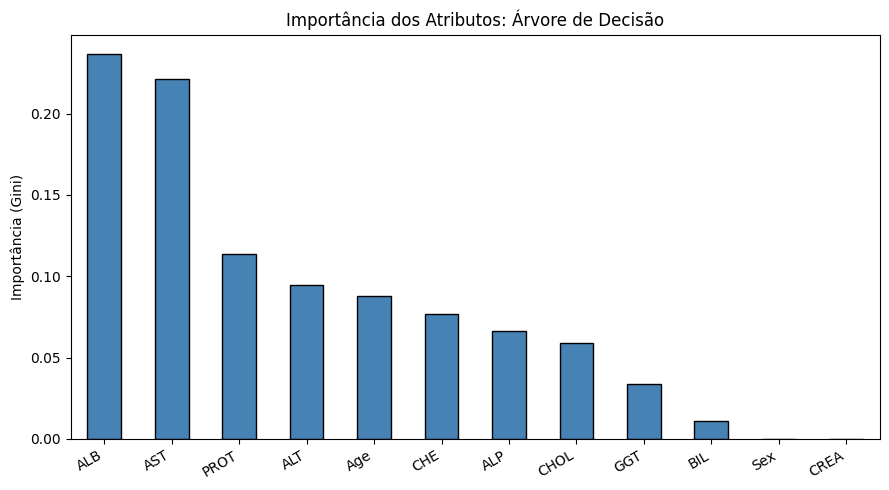


Top 5 atributos mais importantes:
ALB     0.236664
AST     0.221060
PROT    0.113409
ALT     0.094591
Age     0.087680
dtype: float64


In [16]:
# Visualização limitada a 3 níveis para manter legibilidade,
# independente da profundidade real do modelo treinado.

fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(
    dt_final,
    feature_names=list(X.columns),
    class_names=class_names,
    filled=True,
    max_depth=3,
    ax=ax,
    fontsize=9
)
plt.title(f'Árvore de Decisão: primeiros 3 níveis (depth real = {melhor_depth})')
plt.tight_layout()
plt.savefig('figuras/arvore_decisao.png', dpi=150)
plt.show()

# Importância dos atributos segundo o critério de Gini
importancias = pd.Series(
    dt_final.feature_importances_, index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
importancias.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Importância dos Atributos: Árvore de Decisão')
plt.ylabel('Importância (Gini)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('figuras/feature_importance_dt.png', dpi=150)
plt.show()

print("\nTop 5 atributos mais importantes:")
print(importancias.head())

## Passo 7 — Rede Neural Artificial (MLP)

O Perceptron Multicamadas (MLP) é uma rede neural com camadas totalmente conectadas. Sua capacidade de aprender representações não-lineares complexas pode ser vantajosa neste problema. Usamos `Early Stopping` para evitar sobreajuste, pois o dataset de treino tem apenas ~430 instâncias.

### 7.1 — Construção do Modelo

A arquitetura é: entrada (12 atributos) → camada oculta (64 neurônios, ReLU) → camada oculta (32 neurônios, ReLU) → saída (4 classes, Softmax). Usamos `sparse_categorical_crossentropy` porque os rótulos são inteiros, não vetores one-hot.

In [17]:
# Arquitetura: entrada (12) -> oculta (64, ReLU) -> oculta (32, ReLU) -> saída (4, Softmax)
# sparse_categorical_crossentropy é usado porque os rótulos são inteiros, não one-hot.

n_features = X_train_scaled.shape[1]
n_classes  = len(class_names)

def build_mlp(n_features, n_classes, lr=0.001):
    model = keras.Sequential([
        layers.Input(shape=(n_features,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(n_classes, activation='softmax'),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

mlp = build_mlp(n_features, n_classes)
mlp.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,044 (11.89 KB)

 Trainable params: 3,044 (11.89 KB)

 Non-trainable params: 0 (0.00 B)

### 7.2 — Treinamento com Early Stopping

O `Early Stopping` monitora a perda na validação e interrompe o treinamento se não houver melhora por 20 épocas consecutivas, restaurando os pesos do melhor momento. Isso evita sobreajuste sem precisar fixar o número de épocas manualmente.

In [18]:
# Early stopping: se o desempenho na validação não melhorar por 20 épocas
# consecutivas, o treinamento para e os pesos do melhor momento são restaurados.
# Isso evita sobreajuste num dataset com apenas ~430 instâncias de treino.

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

history = mlp.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=200,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stop],
    verbose=1
)

print(f"\nTreinamento encerrado na época {len(history.history['loss'])}")

Epoch 1/200



 1/14 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.9062 - loss: 0.9362


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8628 - loss: 1.3803 - val_accuracy: 0.8587 - val_loss: 1.2944


Epoch 2/200



 1/14 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8750 - loss: 0.9174

...

Epoch 200/200



 1/14 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 1.0000 - loss: 0.0530


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9744 - loss: 0.0945 - val_accuracy: 0.9783 - val_loss: 0.0791


Restoring model weights from the end of the best epoch: 200.



Treinamento encerrado na época 200


### 7.3 — Curva de Aprendizado

Plotamos a evolução da perda e da acurácia ao longo das épocas para treino e validação. Curvas de validação que estabilizam enquanto as de treino continuam melhorando indicam sobreajuste — o Early Stopping mitiga exatamente isso.

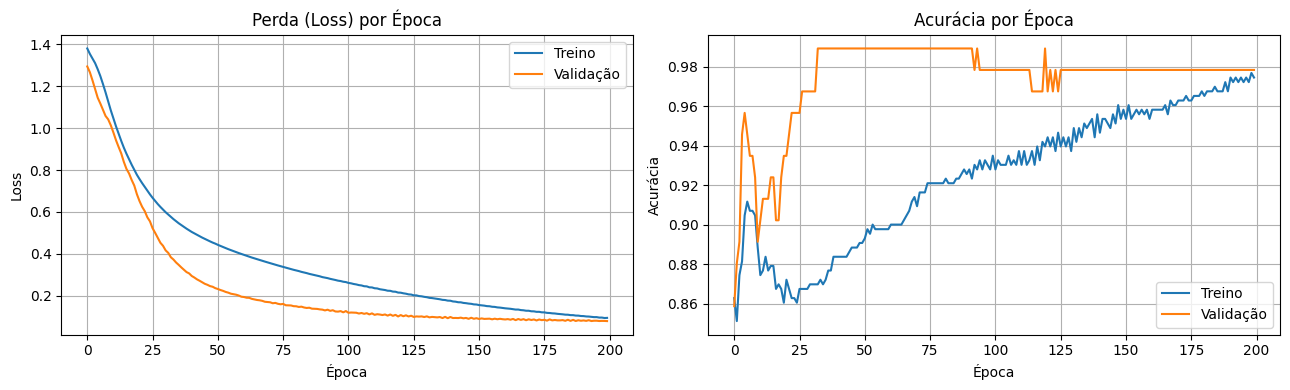

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history['loss'],     label='Treino')
axes[0].plot(history.history['val_loss'], label='Validação')
axes[0].set_title('Perda (Loss) por Época')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['accuracy'],     label='Treino')
axes[1].plot(history.history['val_accuracy'], label='Validação')
axes[1].set_title('Acurácia por Época')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Acurácia')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('figuras/mlp_curva_aprendizado.png', dpi=150)
plt.show()

### 7.4 — Avaliação Final da RNA

Avaliamos o MLP treinado nos conjuntos de validação e **teste**. `np.argmax` converte as probabilidades de saída da softmax para a classe predita.


1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step



1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step



  RNA MLP - Validacao
  Acurácia  : 0.9783
  Precisão  : 0.8750  (macro)
  Recall    : 0.9344  (macro)
  F1-Score  : 0.9002  (macro)

              precision    recall  f1-score   support

 Blood Donor       1.00      0.99      0.99        81
   Cirrhosis       1.00      1.00      1.00         4
    Fibrosis       0.75      1.00      0.86         3
   Hepatitis       0.75      0.75      0.75         4

    accuracy                           0.98        92
   macro avg       0.88      0.93      0.90        92
weighted avg       0.98      0.98      0.98        92



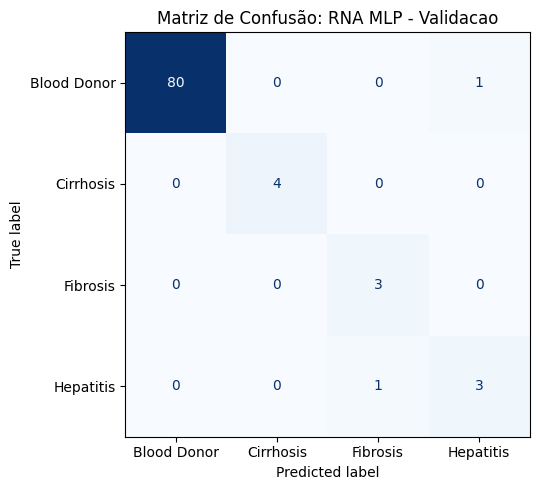

Figura salva em: figuras/cm_mlp_val.png

  RNA MLP - Teste
  Acurácia  : 0.9355
  Precisão  : 0.7231  (macro)
  Recall    : 0.6939  (macro)
  F1-Score  : 0.6954  (macro)

              precision    recall  f1-score   support

 Blood Donor       0.99      0.98      0.98        82
   Cirrhosis       0.57      0.80      0.67         5
    Fibrosis       1.00      0.67      0.80         3
   Hepatitis       0.33      0.33      0.33         3

    accuracy                           0.94        93
   macro avg       0.72      0.69      0.70        93
weighted avg       0.94      0.94      0.94        93



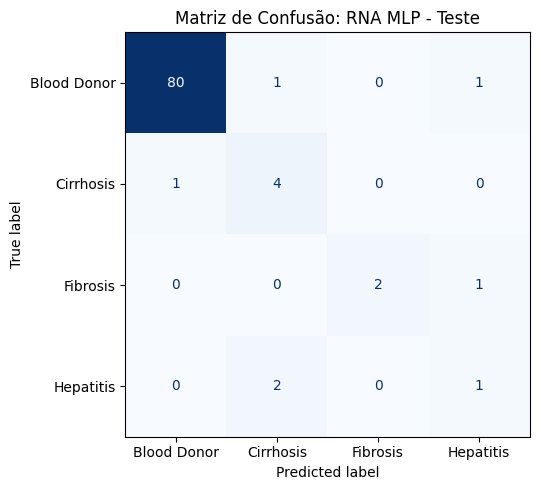

Figura salva em: figuras/cm_mlp_teste.png


In [20]:
y_pred_mlp_val  = np.argmax(mlp.predict(X_val_scaled),  axis=1)
y_pred_mlp_test = np.argmax(mlp.predict(X_test_scaled), axis=1)

metricas_mlp_val  = avaliar_modelo('RNA MLP - Validacao', y_val,  y_pred_mlp_val,  class_names, 'mlp_val')
metricas_mlp_test = avaliar_modelo('RNA MLP - Teste',     y_test, y_pred_mlp_test, class_names, 'mlp_teste')

## Passo 8 — Tabela Comparativa Final

Consolidamos os resultados dos três modelos no conjunto de teste para comparação direta. O F1-Score macro é a métrica principal, pois reflete o desempenho balanceado entre todas as classes, incluindo as minoritárias.


COMPARACAO FINAL — CONJUNTO DE TESTE
                           acuracia  precisao  recall      f1
modelo                                                       
KNN (k=7) - Teste            0.9247    0.6705  0.4833  0.5328
Arvore (depth=10) - Teste    0.9032    0.3868  0.4439  0.4106
RNA MLP - Teste              0.9355    0.7231  0.6939  0.6954

Resultados salvos em 'resultados_supervisionados.csv'


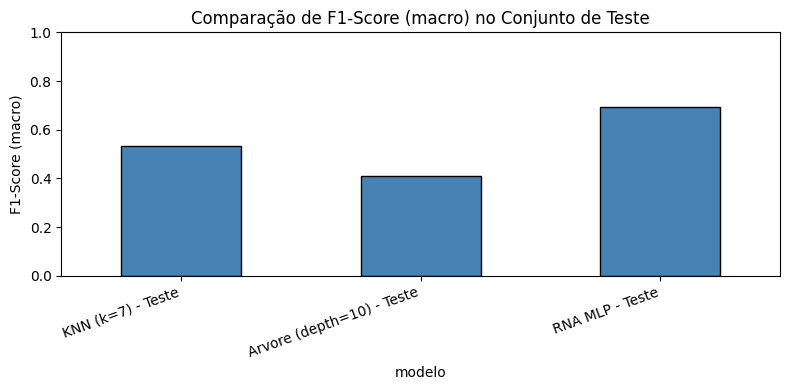

In [21]:
# Consolida os resultados dos três modelos no conjunto de teste.

resultados_finais = pd.DataFrame([
    metricas_knn_test,
    metricas_dt_test,
    metricas_mlp_test,
]).set_index('modelo')

print("\n" + "="*60)
print("COMPARACAO FINAL — CONJUNTO DE TESTE")
print("="*60)
print(resultados_finais.round(4).to_string())

# Salva em CSV para facilitar inclusão no relatório
resultados_finais.to_csv('resultados_supervisionados.csv')
print("\nResultados salvos em 'resultados_supervisionados.csv'")

# Gráfico comparativo de F1-Score
plt.figure(figsize=(8, 4))
resultados_finais['f1'].plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Comparação de F1-Score (macro) no Conjunto de Teste')
plt.ylabel('F1-Score (macro)')
plt.xticks(rotation=20, ha='right')
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig('figuras/comparacao_f1_teste.png', dpi=150)
plt.show()

## Passo 9 — Análise Exploratória (para o Relatório)

Geramos visualizações exploratórias que auxiliam a interpretação dos resultados no relatório: a distribuição das classes (para evidenciar o desbalanceamento) e boxplots dos principais marcadores hepáticos por classe (para verificar se as classes são visualmente separáveis).

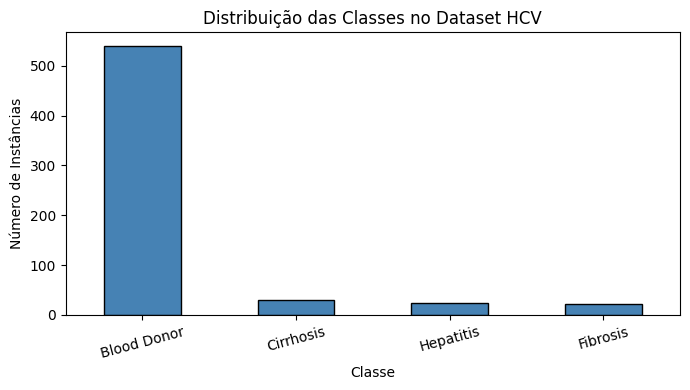

In [22]:
# Distribuição das classes após consolidação
plt.figure(figsize=(7, 4))
df['Category'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Distribuição das Classes no Dataset HCV')
plt.xlabel('Classe')
plt.ylabel('Número de Instâncias')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('figuras/distribuicao_classes.png', dpi=150)
plt.show()

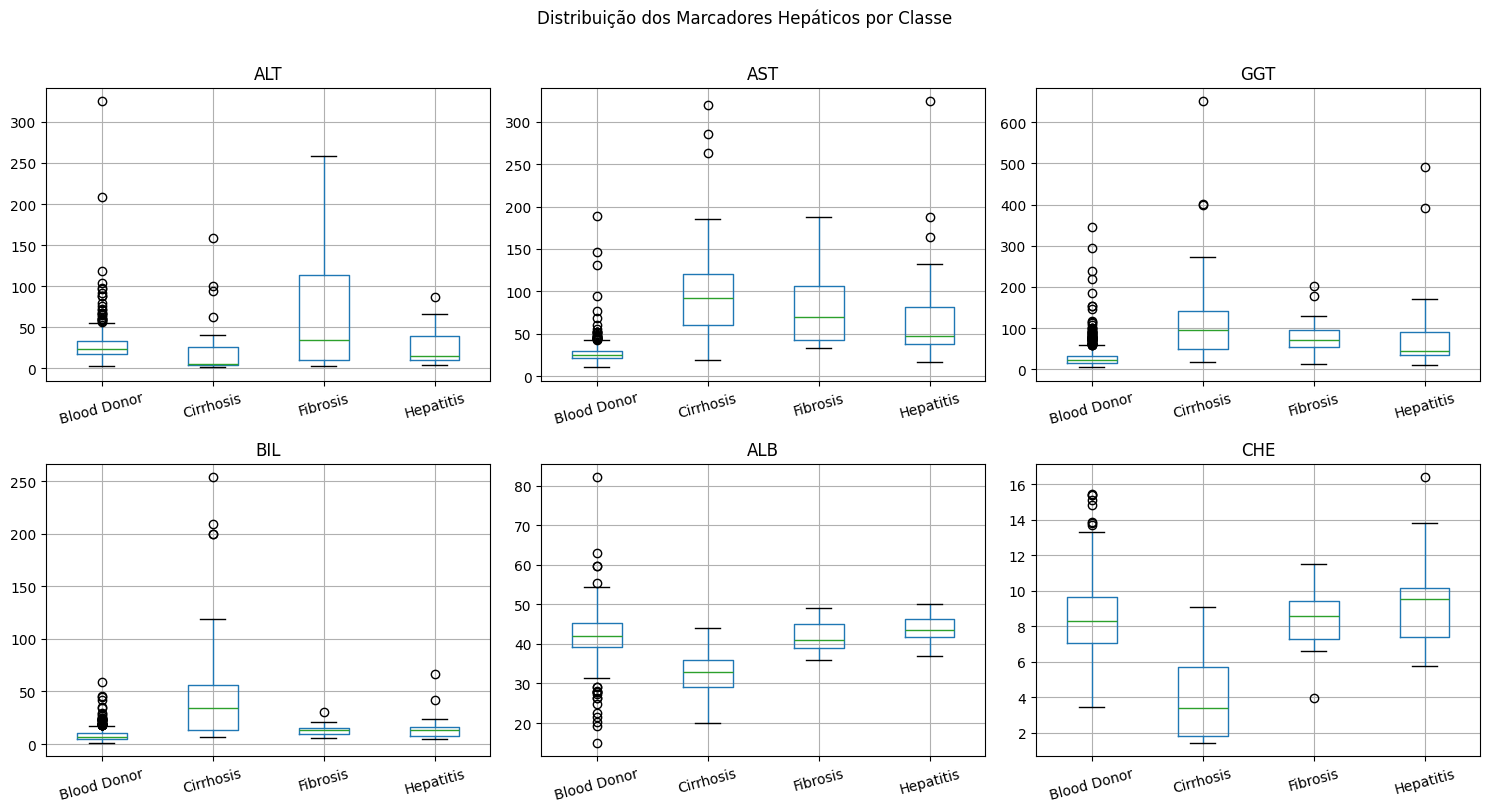

In [23]:
# Boxplots dos principais marcadores hepáticos por classe.
# Esses gráficos ajudam a entender se as classes são visualmente separáveis.
# Nota: usa o df original (antes da divisão), mas após a consolidação dos rótulos.
# Os NaN presentes no df são ignorados automaticamente pelo boxplot.

marcadores = ['ALT', 'AST', 'GGT', 'BIL', 'ALB', 'CHE']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.flatten(), marcadores):
    df.boxplot(column=col, by='Category', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Distribuição dos Marcadores Hepáticos por Classe', y=1.01)
plt.tight_layout()
plt.savefig('figuras/boxplots_marcadores.png', dpi=150, bbox_inches='tight')
plt.show()